In [1]:
import pandas as pd

In [2]:


data = pd.read_csv('data/RNA-Seq-expression-Norilsk2019.csv')

In [3]:
data

,Gene,Species,log_2 fold change,Adjusted p-value
0,ENSG00000181577,homo sapiens,-6.8,6.395631e-214
1,ENSG00000128322,homo sapiens,-6.0,5.979922e-32
2,ENSG00000177606,homo sapiens,5.8,0.000000e+00
3,ENSG00000148600,homo sapiens,-5.8,7.926548e-166
4,ENSG00000164309,homo sapiens,5.6,1.625288e-84
...,...,...,...,...
995,ENSG00000137221,homo sapiens,1.7,5.994751e-72
996,ENSG00000092020,homo sapiens,1.7,3.487785e-71
997,ENSG00000089195,homo sapiens,1.7,8.793077e-71
998,ENSG00000179832,homo sapiens,-1.7,9.521317e-71


c:\python_env\biologia_computacional\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


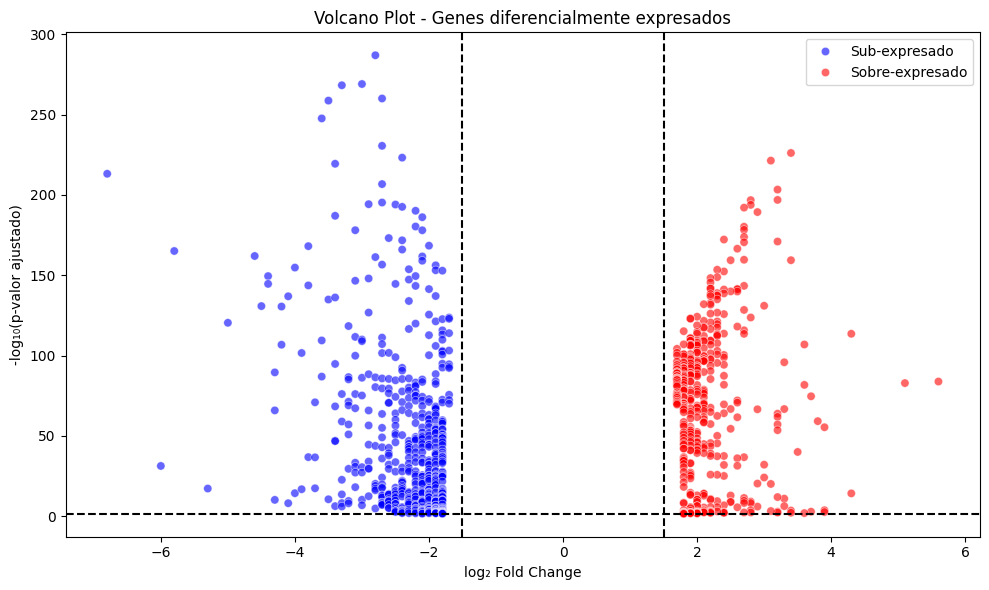

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Asumiendo que tu DataFrame se llama "data"
df = data.copy()

# Umbrales definidos
fc_threshold = 1.5  # Cambio de al menos 2^(1.5) ≈ 2.8 veces
pval_threshold = 0.05

# Clasificación
df['Significativo'] = 'No significativo'
df.loc[(df['log_2 fold change'] >= fc_threshold) & (df['Adjusted p-value'] < pval_threshold), 'Significativo'] = 'Sobre-expresado'
df.loc[(df['log_2 fold change'] <= -fc_threshold) & (df['Adjusted p-value'] < pval_threshold), 'Significativo'] = 'Sub-expresado'

# Volcano plot
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x='log_2 fold change',
    y=-np.log10(df['Adjusted p-value']),
    hue='Significativo',
    palette={'Sobre-expresado': 'red', 'Sub-expresado': 'blue', 'No significativo': 'gray'},
    alpha=0.6
)
plt.axhline(-np.log10(pval_threshold), ls='--', color='black')
plt.axvline(fc_threshold, ls='--', color='black')
plt.axvline(-fc_threshold, ls='--', color='black')
plt.xlabel('log₂ Fold Change')
plt.ylabel('-log₁₀(p-valor ajustado)')
plt.title('Volcano Plot - Genes diferencialmente expresados')
plt.legend()
plt.tight_layout()
plt.show()


In [6]:
df

,Gene,Species,log_2 fold change,Adjusted p-value,Significativo
0,ENSG00000181577,homo sapiens,-6.8,6.395631e-214,Sub-expresado
1,ENSG00000128322,homo sapiens,-6.0,5.979922e-32,Sub-expresado
2,ENSG00000177606,homo sapiens,5.8,0.000000e+00,Sobre-expresado
3,ENSG00000148600,homo sapiens,-5.8,7.926548e-166,Sub-expresado
4,ENSG00000164309,homo sapiens,5.6,1.625288e-84,Sobre-expresado
...,...,...,...,...,...
995,ENSG00000137221,homo sapiens,1.7,5.994751e-72,Sobre-expresado
996,ENSG00000092020,homo sapiens,1.7,3.487785e-71,Sobre-expresado
997,ENSG00000089195,homo sapiens,1.7,8.793077e-71,Sobre-expresado
998,ENSG00000179832,homo sapiens,-1.7,9.521317e-71,Sub-expresado


In [7]:
import mygene

mg = mygene.MyGeneInfo()

# Filtrar genes sobre-expresados
genes_up = df[(df['log_2 fold change'] >= fc_threshold) & (df['Adjusted p-value'] < pval_threshold)]
gene_ids = genes_up['Gene'].tolist()

# Consulta a MyGene
results = mg.querymany(gene_ids, scopes='ensembl.gene', fields='symbol,name,go', species='human')

# Convertir a DataFrame
go_df = pd.DataFrame(results)

# Filtrar y mostrar columnas relevantes
go_df = go_df[['query', 'symbol', 'name', 'go']]
go_df.head()


Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
8 input query terms found dup hits:	[('ENSG00000137959', 5), ('ENSG00000165949', 4), ('ENSG00000137965', 4), ('ENSG00000187608', 2), ('E


,query,symbol,name,go
0,ENSG00000177606,JUN,"Jun proto-oncogene, AP-1 transcription factor ...","{'BP': [{'evidence': 'IDA', 'gocategory': 'BP'..."
1,ENSG00000164309,CMYA5,cardiomyopathy associated 5,"{'CC': [{'evidence': 'IEA', 'gocategory': 'CC'..."
2,ENSG00000184545,DUSP8,dual specificity phosphatase 8,"{'BP': [{'evidence': 'IBA', 'gocategory': 'BP'..."
3,ENSG00000085465,OVGP1,oviductal glycoprotein 1,"{'BP': [{'evidence': 'IEA', 'gocategory': 'BP'..."
4,ENSG00000087589,CASS4,Cas scaffold protein family member 4,"{'BP': [{'evidence': 'IEA', 'gocategory': 'BP'..."


In [8]:
go_df

,query,symbol,name,go
0,ENSG00000177606,JUN,"Jun proto-oncogene, AP-1 transcription factor ...","{'BP': [{'evidence': 'IDA', 'gocategory': 'BP'..."
1,ENSG00000164309,CMYA5,cardiomyopathy associated 5,"{'CC': [{'evidence': 'IEA', 'gocategory': 'CC'..."
2,ENSG00000184545,DUSP8,dual specificity phosphatase 8,"{'BP': [{'evidence': 'IBA', 'gocategory': 'BP'..."
3,ENSG00000085465,OVGP1,oviductal glycoprotein 1,"{'BP': [{'evidence': 'IEA', 'gocategory': 'BP'..."
4,ENSG00000087589,CASS4,Cas scaffold protein family member 4,"{'BP': [{'evidence': 'IEA', 'gocategory': 'BP'..."
...,...,...,...,...
442,ENSG00000278053,DDX52,DExD-box helicase 52,"{'BP': [{'evidence': 'IBA', 'gocategory': 'BP'..."
443,ENSG00000137221,TJAP1,tight junction associated protein 1,"{'BP': [{'evidence': 'IBA', 'gocategory': 'BP'..."
444,ENSG00000092020,PPP2R3C,protein phosphatase 2 regulatory subunit B''gamma,"{'BP': [{'evidence': 'IBA', 'gocategory': 'BP'..."
445,ENSG00000089195,TRMT6,tRNA methyltransferase 6 non-catalytic subunit,"{'BP': [{'evidence': 'IDA', 'gocategory': 'BP'..."


In [9]:
def extract_terms(go_entry, category):
    if isinstance(go_entry, dict) and category in go_entry:
        terms = go_entry[category]
        if isinstance(terms, dict):  # en caso de que solo haya un término
            terms = [terms]
        return [f"{t['term']} (GO:{t['id']})" for t in terms]
    return []

go_df['GO_BP'] = go_df['go'].apply(lambda x: extract_terms(x, 'BP'))
go_df['GO_MF'] = go_df['go'].apply(lambda x: extract_terms(x, 'MF'))
go_df['GO_CC'] = go_df['go'].apply(lambda x: extract_terms(x, 'CC'))


In [10]:
go_df

,query,symbol,name,go,GO_BP,GO_MF,GO_CC
0,ENSG00000177606,JUN,"Jun proto-oncogene, AP-1 transcription factor ...","{'BP': [{'evidence': 'IDA', 'gocategory': 'BP'...",[negative regulation of transcription by RNA p...,[transcription cis-regulatory region binding (...,"[nuclear chromosome (GO:GO:0000228), chromatin..."
1,ENSG00000164309,CMYA5,cardiomyopathy associated 5,"{'CC': [{'evidence': 'IEA', 'gocategory': 'CC'...",[],[],"[nucleus (GO:GO:0005634), nucleus (GO:GO:00056..."
2,ENSG00000184545,DUSP8,dual specificity phosphatase 8,"{'BP': [{'evidence': 'IBA', 'gocategory': 'BP'...","[signal transduction (GO:GO:0007165), dephosph...",[phosphoprotein phosphatase activity (GO:GO:00...,"[nucleus (GO:GO:0005634), cytoplasm (GO:GO:000..."
3,ENSG00000085465,OVGP1,oviductal glycoprotein 1,"{'BP': [{'evidence': 'IEA', 'gocategory': 'BP'...",[carbohydrate metabolic process (GO:GO:0005975...,"[chitinase activity (GO:GO:0004568), chitin bi...","[extracellular region (GO:GO:0005576), cytosol..."
4,ENSG00000087589,CASS4,Cas scaffold protein family member 4,"{'BP': [{'evidence': 'IEA', 'gocategory': 'BP'...","[cell adhesion (GO:GO:0007155), cell surface r...","[protein binding (GO:GO:0005515), protein tyro...","[cytoplasm (GO:GO:0005737), cytoplasm (GO:GO:0..."
...,...,...,...,...,...,...,...
442,ENSG00000278053,DDX52,DExD-box helicase 52,"{'BP': [{'evidence': 'IBA', 'gocategory': 'BP'...","[maturation of SSU-rRNA (GO:GO:0030490), matur...","[nucleotide binding (GO:GO:0000166), nucleic a...","[nucleus (GO:GO:0005634), nucleoplasm (GO:GO:0..."
443,ENSG00000137221,TJAP1,tight junction associated protein 1,"{'BP': [{'evidence': 'IBA', 'gocategory': 'BP'...","[Golgi organization (GO:GO:0007030), Golgi org...",[protein binding (GO:GO:0005515)],"[cytoplasm (GO:GO:0005737), endosome (GO:GO:00..."
444,ENSG00000092020,PPP2R3C,protein phosphatase 2 regulatory subunit B''gamma,"{'BP': [{'evidence': 'IBA', 'gocategory': 'BP'...",[microtubule cytoskeleton organization (GO:GO:...,"[protein binding (GO:GO:0005515), metal ion bi...","[nucleus (GO:GO:0005634), nucleoplasm (GO:GO:0..."
445,ENSG00000089195,TRMT6,tRNA methyltransferase 6 non-catalytic subunit,"{'BP': [{'evidence': 'IDA', 'gocategory': 'BP'...","[mRNA processing (GO:GO:0006397), tRNA process...","[RNA binding (GO:GO:0003723), protein binding ...","[nucleus (GO:GO:0005634), nucleus (GO:GO:00056..."
